### IPL Match Analysis
#### Introduction

In this project, we perform Exploratory Data Analysis (EDA) using Python to identify trends, discover patterns, clean the data, and generate meaningful business insights.

Objectives
The objectives of this project are:

Understand the structure of the dataset.
Clean missing and inconsistent data.
Convert data into appropriate formats.
Analyze ratings, installs, reviews, prices, and app categories.
Create meaningful visualizations.
Answer business-related questions using Python.
Provide recommendations based on the analysis.

In [4]:
# The following libraries are used for data manipulation, numerical computation, and data visualization.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Reading the csv file using the read_csv method of Pandas library
df=pd.read_csv('/kaggle/input/datasets/sonalsharma98/matches-and-delivery/matches.csv')


In [8]:
# Displays Top 10 Rows
df.head(10)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
5,6,2017,Hyderabad,2017-04-09,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN
6,7,2017,Mumbai,2017-04-09,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN
7,8,2017,Indore,2017-04-10,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
8,9,2017,Pune,2017-04-11,Delhi Daredevils,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Delhi Daredevils,97,0,SV Samson,Maharashtra Cricket Association Stadium,AY Dandekar,S Ravi,NaN
9,10,2017,Mumbai,2017-04-12,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN


In [6]:
# Displays rows and columns
df.shape

(756, 18)

In [ ]:
# Displays the columns
df.columns


In [ ]:
# Displays the values within all the columns
df.values

In [9]:
# Dataset info like total rows & columns, datatypes, memory usage, non-null values, etc

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [10]:
# check for missing values in each column

df.isna().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

**We have missing values in columns like city, winner, player_of_match, umpire1, umpire2, umpire3**

In [13]:
# Calculate missing value percentage

miss_val= (df.isna().sum()/len(df))*100
round(miss_val,2)

id                  0.00
season              0.00
city                0.93
date                0.00
team1               0.00
team2               0.00
toss_winner         0.00
toss_decision       0.00
result              0.00
dl_applied          0.00
winner              0.53
win_by_runs         0.00
win_by_wickets      0.00
player_of_match     0.53
venue               0.00
umpire1             0.26
umpire2             0.26
umpire3            84.26
dtype: float64

In [14]:
# Dropping those rows which have less number of null values
df = df.dropna(subset=["winner", "umpire1","umpire2"])

In [29]:
# Filling missing values in city columns by mode

df['city']=df['city'].fillna(df['city'].mode()[0])

In [26]:
# umpire3 column has around 80–90% missing values
df = df.drop(columns=["umpire3"])

In [27]:
# Verification for the missing values

df.isnull().sum()

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
dtype: int64

In [22]:
# Check for duplicate records

df.duplicated().sum()    # No duplicates

np.int64(0)

In [31]:
# checks datatypes
df.dtypes

id                  int64
season              int64
city               object
date               object
team1              object
team2              object
toss_winner        object
toss_decision      object
result             object
dl_applied          int64
winner             object
win_by_runs         int64
win_by_wickets      int64
player_of_match    object
venue              object
umpire1            object
umpire2            object
dtype: object

In [37]:
# Coverting datatype of the date column from object to datetime

df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors='coerce')

In [39]:
# Creating new year columns

df['Year']=df['date'].dt.year

In [40]:
# Creating Month column
df["Month"] = df["date"].dt.month_name()

In [ ]:
# creating weekdays column displaying day name
df["Weekday"] = df["date"].dt.day_name()

In [42]:
df["Match_Type"] = np.where(
    df["win_by_runs"] > 0,
    "Batting First",
    "Chasing"
)
df['Match_Type']

0      Batting First
1            Chasing
2            Chasing
3            Chasing
5            Chasing
           ...      
750          Chasing
751          Chasing
752          Chasing
754          Chasing
755    Batting First
Name: Match_Type, Length: 750, dtype: object

### Perform exploratory analysis 
 


In [43]:
# Statistical analysis for numerical data
df.describe()

,id,season,date,dl_applied,win_by_runs,win_by_wickets,Year
count,750.000000,750.000000,632,750.000000,750.000000,750.000000,632.000000
mean,1774.281333,2013.424000,2012-10-20 04:42:31.898734080,0.025333,13.369333,3.374667,2012.477848
min,1.000000,2008.000000,2008-04-18 00:00:00,0.000000,0.000000,0.000000,2008.000000
25%,189.250000,2011.000000,2010-04-10 18:00:00,0.000000,0.000000,0.000000,2010.000000
50%,377.500000,2013.000000,2012-05-20 00:00:00,0.000000,0.000000,4.000000,2012.000000
75%,565.750000,2016.000000,2015-04-20 06:00:00,0.000000,19.000000,6.000000,2015.000000
max,11415.000000,2019.000000,2017-05-21 00:00:00,1.000000,146.000000,10.000000,2017.000000
std,3441.199080,3.363427,NaN,0.157240,23.539720,3.390027,2.771742


In [44]:
# Statistical analysis for non-numerical data
df.describe(include='object')

,city,team1,team2,toss_winner,toss_decision,result,winner,player_of_match,venue,umpire1,umpire2,Month,Match_Type
count,750,750,750,750,750,750,750,750,750,750,750,632,750
unique,33,15,15,15,2,2,15,226,41,61,65,4,2
top,Mumbai,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,field,normal,Mumbai Indians,CH Gayle,Eden Gardens,HDPK Dharmasena,S Ravi,May,Chasing
freq,101,101,95,98,459,741,109,21,77,72,57,306,414


In [45]:
# Statistical analysis for all data
df.describe(include='all')

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,Year,Month,Match_Type
count,750.000000,750.000000,750,632,750,750,750,750,750,750.000000,750,750.000000,750.000000,750,750,750,750,632.000000,632,750
unique,NaN,NaN,33,NaN,15,15,15,2,2,NaN,15,NaN,NaN,226,41,61,65,NaN,4,2
top,NaN,NaN,Mumbai,NaN,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,field,normal,NaN,Mumbai Indians,NaN,NaN,CH Gayle,Eden Gardens,HDPK Dharmasena,S Ravi,NaN,May,Chasing
freq,NaN,NaN,101,NaN,101,95,98,459,741,NaN,109,NaN,NaN,21,77,72,57,NaN,306,414
mean,1774.281333,2013.424000,NaN,2012-10-20 04:42:31.898734080,NaN,NaN,NaN,NaN,NaN,0.025333,NaN,13.369333,3.374667,NaN,NaN,NaN,NaN,2012.477848,NaN,NaN
min,1.000000,2008.000000,NaN,2008-04-18 00:00:00,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,2008.000000,NaN,NaN
25%,189.250000,2011.000000,NaN,2010-04-10 18:00:00,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,2010.000000,NaN,NaN
50%,377.500000,2013.000000,NaN,2012-05-20 00:00:00,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,4.000000,NaN,NaN,NaN,NaN,2012.000000,NaN,NaN
75%,565.750000,2016.000000,NaN,2015-04-20 06:00:00,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,19.000000,6.000000,NaN,NaN,NaN,NaN,2015.000000,NaN,NaN
max,11415.000000,2019.000000,NaN,2017-05-21 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,146.000000,10.000000,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN


In [6]:
# Average of all numerical columns
df.mean(numeric_only=True)

id                1792.178571
season            2013.444444
dl_applied           0.025132
win_by_runs         13.283069
win_by_wickets       3.350529
dtype: float64

In [ ]:
# Median of all numerical columns
df.median(numeric_only=True)

In [7]:
# Mode of all numerical columns
df.mode(numeric_only=True)

,id,season,dl_applied,win_by_runs,win_by_wickets
0,1,2013.0,0.0,0.0,0.0
1,2,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
751,11347,NaN,NaN,NaN,NaN
752,11412,NaN,NaN,NaN,NaN
753,11413,NaN,NaN,NaN,NaN
754,11414,NaN,NaN,NaN,NaN


In [8]:
# Maximum of all numerical columns
df.max(numeric_only=True)

id                11415
season             2019
dl_applied            1
win_by_runs         146
win_by_wickets       10
dtype: int64

In [9]:
# Minimum of all numerical columns
df.mean(numeric_only=True)

id                1792.178571
season            2013.444444
dl_applied           0.025132
win_by_runs         13.283069
win_by_wickets       3.350529
dtype: float64

In [10]:
# Standard deviation of all numerical columns
df.std(numeric_only=True)

id                3464.478148
season               3.366895
dl_applied           0.156630
win_by_runs         23.471144
win_by_wickets       3.387963
dtype: float64

### Business Questions and Visualizations

1] Which team has won the most IPL matches?

In [48]:
winner=df['winner'].mode()[0]

In [43]:
# Second way of same operation
# Also converting series result to Dataframe
winner1=df['winner'].value_counts().reset_index()
winner1

,winner,count
0,Mumbai Indians,109
1,Chennai Super Kings,100
2,Kolkata Knight Riders,92
3,Royal Challengers Bangalore,84
4,Kings XI Punjab,82
5,Rajasthan Royals,75
6,Delhi Daredevils,67
7,Sunrisers Hyderabad,58
8,Deccan Chargers,29
9,Gujarat Lions,13


/tmp/ipykernel_58/3760567033.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


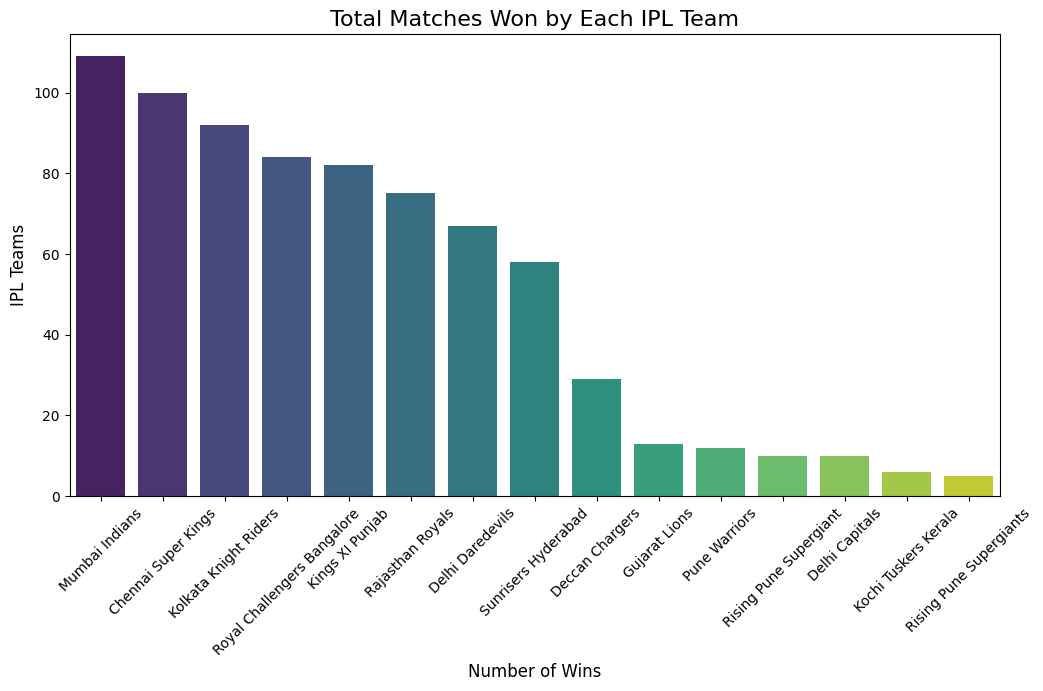

In [47]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=winner1,
    x="winner",
    y="count",
    palette="viridis"
)

plt.title("Total Matches Won by Each IPL Team", fontsize=16)
plt.xlabel("Number of Wins", fontsize=12)
plt.ylabel("IPL Teams", fontsize=12)
plt.xticks(rotation=45)

plt.show()

***The visualization shows that Mumbai Indians has recorded the highest number of victories in the IPL dataset.***

2] Which Player of the Match has won the most awards?

In [84]:
top=df['player_of_match'].value_counts().reset_index()
top

,player_of_match,count
0,CH Gayle,21
1,AB de Villiers,20
2,MS Dhoni,17
3,RG Sharma,17
4,DA Warner,17
...,...,...
221,Imran Tahir,1
222,K Paul,1
223,K Ahmed,1
224,S Gill,1


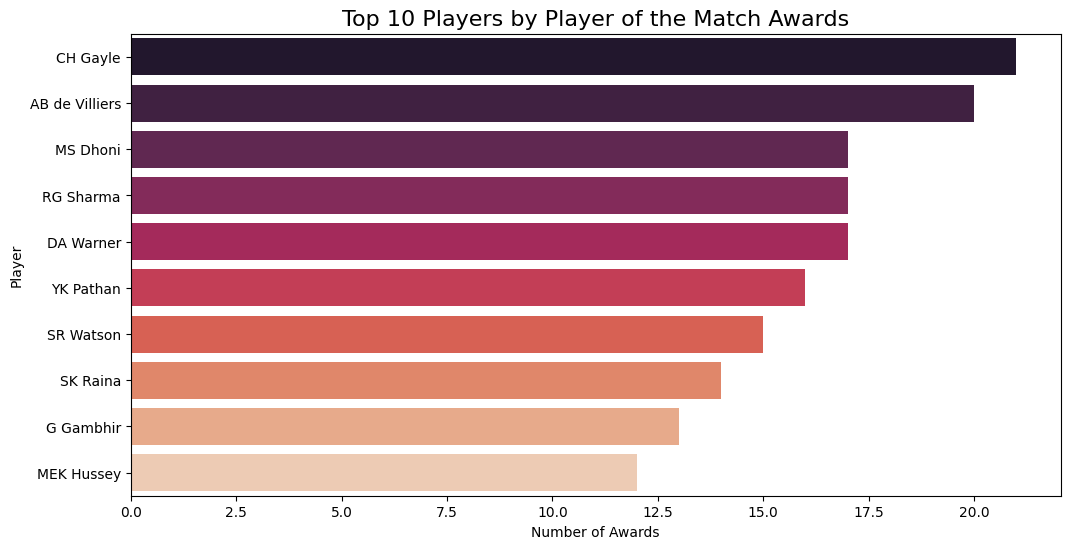

In [86]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top.head(10),
    x="count",
    y="player_of_match",
    hue="player_of_match",
    palette="rocket",
    legend=False
)

plt.title("Top 10 Players by Player of the Match Awards", fontsize=16)
plt.xlabel("Number of Awards")
plt.ylabel("Player")

plt.show()

***The analysis shows that CH Gayle has received the highest number of Player of the Match awards***

3] Average wins by wickets per venue?

In [28]:
wins=df.groupby('venue')['win_by_wickets'].mean().sort_values(ascending=False)
print(wins.round(2))

venue
Holkar Cricket Stadium                                  6.44
Green Park                                              5.50
IS Bindra Stadium                                       5.00
Saurashtra Cricket Association Stadium                  4.80
New Wanderers Stadium                                   4.38
Sharjah Cricket Stadium                                 4.33
Sawai Mansingh Stadium                                  4.30
Shaheed Veer Narayan Singh International Stadium        4.17
SuperSport Park                                         4.08
ACA-VDCA Stadium                                        4.00
Maharashtra Cricket Association Stadium                 3.95
Dr DY Patil Sports Academy                              3.76
Rajiv Gandhi International Stadium, Uppal               3.68
Punjab Cricket Association Stadium, Mohali              3.63
Eden Gardens                                            3.57
M Chinnaswamy Stadium                                   3.47
JSCA International

4] Does winning the toss increase the chances of winning the match?

In [51]:
# Comparing the entire column in order to find the relation between winner and toss winner
mask=df["toss_winner"] == df["winner"]

In [60]:
df['matchwin']=mask
df['matchwin']

0      False
1       True
2       True
3       True
4       True
       ...  
751     True
752    False
753     True
754     True
755     True
Name: matchwin, Length: 756, dtype: bool

In [59]:
var = df["matchwin"].mean() * 100

print(f"Toss winner won the match in {var:.2f}%")

Toss winner won the match in 51.98%


In [63]:
data=df['matchwin'].value_counts().reset_index()

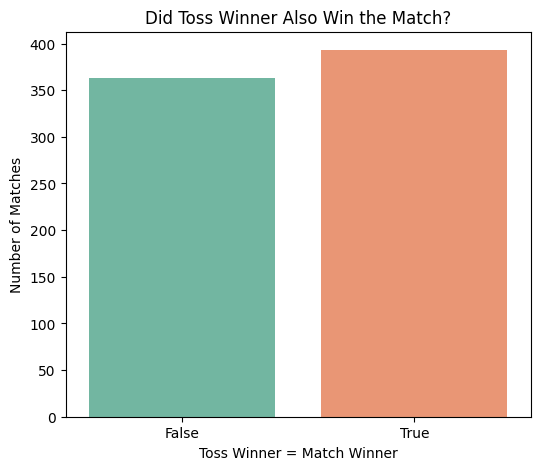

In [65]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=data,
    x="matchwin",
    y="count",
    hue="matchwin",
    palette="Set2",
    legend=False
)

plt.title("Does winning the toss increase the chances of winning the match")
plt.xlabel("Toss Winner is match winner?")
plt.ylabel("Number of Matches")

plt.show()

5] Which venues host the highest number of IPL matches?

In [77]:
matches = (
    df.groupby("venue").size().sort_values(ascending=False).reset_index(name='total_matches')
)

matches

,venue,matches
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,73
3,Feroz Shah Kotla,67
4,"Rajiv Gandhi International Stadium, Uppal",56
5,"MA Chidambaram Stadium, Chepauk",49
6,Sawai Mansingh Stadium,47
7,"Punjab Cricket Association Stadium, Mohali",35
8,Maharashtra Cricket Association Stadium,21
9,Subrata Roy Sahara Stadium,17


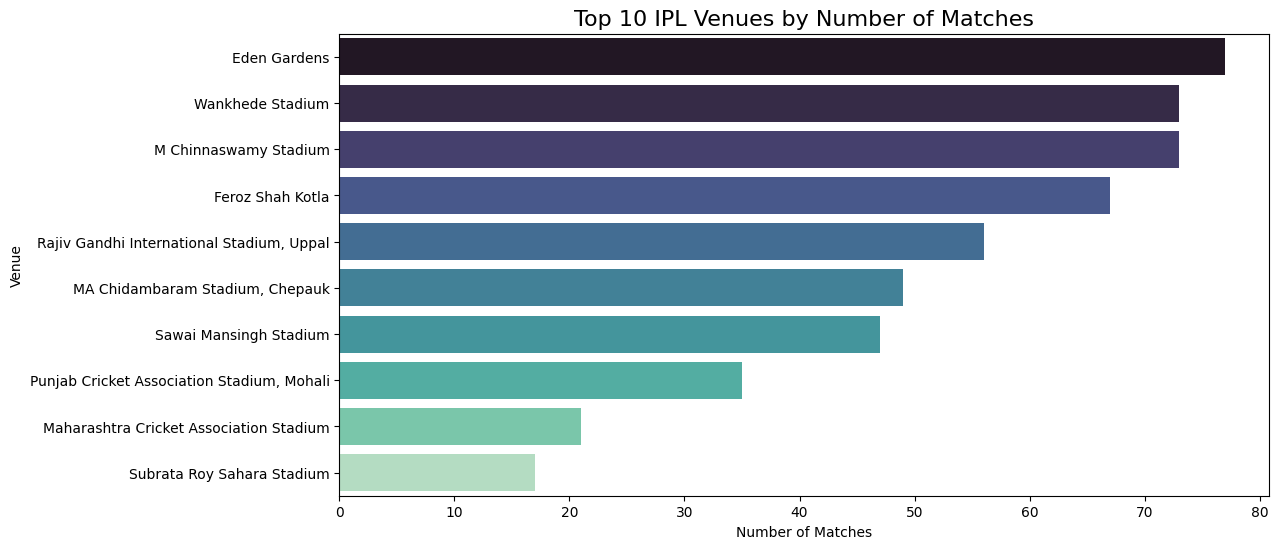

In [81]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=matches.head(10),
    x="matches",
    y="venue",
    hue="venue",
    palette="mako",
    legend=False
)

plt.title("Top 10 IPL Venues by Number of Matches", fontsize=16)
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.show()

***The analysis shows that Eden Gardens has hosted the highest number of IPL matches.***

### Summary
This project performed Exploratory Data Analysis (EDA) on the Indian Premier League (IPL) Matches dataset to analyze team performance, match outcomes, player achievements, and venue-wise trends. After cleaning and preprocessing the data, various analyses and visualizations were created using Python, Pandas, Matplotlib, and Seaborn to identify winning patterns, top-performing teams and players, toss decisions, and seasonal trends.

The analysis provided valuable insights into team performance, match-winning factors, and venue influence, helping understand key aspects of the tournament. Overall, this project demonstrates how data analytics can support teams, coaches, analysts, and cricket enthusiasts in making data-driven decisions and evaluating performance trends in the IPL.